In [1]:
!pip install -q scikit-learn==1.6.1 langchain-openai langchain-core pandas numpy pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 14.2 MB/s eta 0:00:00


In [21]:
import json
import pickle
import re
import numpy as np
import pandas as pd

from typing import Dict, Literal
from pydantic import BaseModel, Field

# Needed so pickle can reconstruct the saved scaler objects
class TemperatureScaler:
    def __init__(self):
        self.temperature = 1.0

    def fit(self, logits, true_labels):
        return self

    def predict_proba(self, probs):
        probs = np.asarray(probs, dtype=float)
        eps = 1e-12
        logits = np.log((probs + eps) / (1 - probs + eps))
        scaled = 1 / (1 + np.exp(-(logits / self.temperature)))
        return scaled

In [22]:
with open("week3_artifacts.pkl", "rb") as f:
    week3_artifacts = pickle.load(f)

feature_columns = week3_artifacts["feature_columns"]
lr_clf = week3_artifacts["lr_classifier"]
rf_clf = week3_artifacts["rf_classifier"]
lr_temp_scaler = week3_artifacts["lr_temp_scaler"]
rf_temp_scaler = week3_artifacts["rf_temp_scaler"]
selected_model_name = week3_artifacts["selected_model_name"]
lr_importance_df = week3_artifacts["lr_importance_df"]
rf_importance_df = week3_artifacts["rf_importance_df"]
calibration_summary_df = week3_artifacts["calibration_summary_df"]

print("Loaded Week 3 artifacts successfully.")
print("Selected model:", selected_model_name)
print("Feature columns:", feature_columns)

Loaded Week 3 artifacts successfully.
Selected model: random_forest
Feature columns: ['avg_word_length', 'type_token_ratio', 'hapax_ratio', 'stopword_ratio', 'avg_words_per_sentence', 'avg_sentence_length', 'sentence_length_variance', 'paragraph_count', 'period_ratio', 'capital_letter_ratio', 'comma_ratio', 'exclamation_ratio', 'question_ratio', 'long_word_ratio']


In [23]:
def extract_stylometry_features(text: str) -> Dict[str, float]:
    """
    Exact Week 4 standalone extractor aligned to the 14-feature Week 3 model.
    """
    text = str(text).strip()

    words = re.findall(r"\b\w+\b", text.lower())
    word_count = len(words)

    if word_count == 0:
        return {
            "avg_word_length": 0.0,
            "type_token_ratio": 0.0,
            "hapax_ratio": 0.0,
            "stopword_ratio": 0.0,
            "avg_words_per_sentence": 0.0,
            "avg_sentence_length": 0.0,
            "sentence_length_variance": 0.0,
            "paragraph_count": 0,
            "period_ratio": 0.0,
            "capital_letter_ratio": 0.0,
            "comma_ratio": 0.0,
            "exclamation_ratio": 0.0,
            "question_ratio": 0.0,
            "long_word_ratio": 0.0,
        }

    avg_word_length = np.mean([len(w) for w in words])

    unique_words = set(words)
    type_token_ratio = len(unique_words) / word_count

    word_freq = {}
    for w in words:
        word_freq[w] = word_freq.get(w, 0) + 1
    hapax_ratio = sum(1 for w in word_freq if word_freq[w] == 1) / word_count

    stopwords = {
        "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
        "of", "with", "by", "from", "as", "is", "was", "are", "were", "be",
        "been", "being", "have", "has", "had", "do", "does", "did", "will",
        "would", "could", "should", "may", "might", "must", "can", "this",
        "that", "these", "those", "i", "you", "he", "she", "it", "we", "they"
    }
    stopword_ratio = sum(1 for w in words if w in stopwords) / word_count

    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    sentence_lengths = [len(re.findall(r"\b\w+\b", s)) for s in sentences]

    avg_sentence_length = np.mean(sentence_lengths) if sentence_lengths else 0.0
    sentence_length_variance = np.var(sentence_lengths) if len(sentence_lengths) > 1 else 0.0
    avg_words_per_sentence = word_count / len(sentences) if len(sentences) > 0 else 0.0

    char_count = len(text) if len(text) > 0 else 1
    period_ratio = text.count(".") / char_count
    comma_ratio = text.count(",") / char_count
    exclamation_ratio = text.count("!") / char_count
    question_ratio = text.count("?") / char_count
    capital_letter_ratio = sum(1 for c in text if c.isupper()) / char_count

    paragraphs = [p for p in text.split("\n\n") if p.strip()]
    paragraph_count = len(paragraphs) if paragraphs else 1

    long_word_ratio = sum(1 for w in words if len(w) > 6) / word_count

    return {
        "avg_word_length": round(float(avg_word_length), 3),
        "type_token_ratio": round(float(type_token_ratio), 3),
        "hapax_ratio": round(float(hapax_ratio), 3),
        "stopword_ratio": round(float(stopword_ratio), 3),
        "avg_words_per_sentence": round(float(avg_words_per_sentence), 3),
        "avg_sentence_length": round(float(avg_sentence_length), 3),
        "sentence_length_variance": round(float(sentence_length_variance), 3),
        "paragraph_count": int(paragraph_count),
        "period_ratio": round(float(period_ratio), 4),
        "capital_letter_ratio": round(float(capital_letter_ratio), 4),
        "comma_ratio": round(float(comma_ratio), 4),
        "exclamation_ratio": round(float(exclamation_ratio), 4),
        "question_ratio": round(float(question_ratio), 4),
        "long_word_ratio": round(float(long_word_ratio), 3),
    }

print("Embedded Week 3-aligned 14-feature extractor created.")

Embedded Week 3-aligned 14-feature extractor created.


In [24]:
from google.colab import userdata
from langchain_openai import ChatOpenAI

openai_api_key = userdata.get("OPENAI_API_KEY")
if not openai_api_key:
    raise ValueError("OPENAI_API_KEY not found in Colab secrets.")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=openai_api_key
)

print("Explanation LLM initialized successfully.")

Explanation LLM initialized successfully.


In [25]:
from langchain_core.prompts import ChatPromptTemplate

class FinalDetectionOutput(BaseModel):
    review_text: str = Field(description="Original review text")
    model_used: Literal["logistic_regression", "random_forest"] = Field(
        description="Classifier used"
    )
    calibrated: bool = Field(description="Whether probability calibration was applied")
    ai_probability: float = Field(ge=0.0, le=1.0)
    ai_likeness_score: int = Field(ge=0, le=100)
    uncertainty_band: Literal["likely human-written", "uncertain", "likely AI-generated"]
    predicted_label: Literal["Human", "AI"]
    top_features: Dict[str, float] = Field(
        description="Top stylometric feature values used for the explanation"
    )
    explanation: str = Field(
        description="Short explanation grounded only in the provided model output and top features"
    )

explanation_prompt = ChatPromptTemplate.from_template(
    """
You are helping explain an AI-generated text detector for hotel reviews.

Use ONLY the structured evidence below.
Do not invent any evidence.
Do not mention features that are not listed.
Do not overstate certainty beyond the uncertainty band.
Keep the explanation short: 2 to 3 sentences.

Structured evidence:
- Review text: {review_text}
- AI probability: {ai_probability}
- AI-likeness score: {ai_likeness_score}
- Uncertainty band: {uncertainty_band}
- Predicted label: {predicted_label}
- Top stylometric features: {top_features}

Return valid JSON only in this exact format:
{{
  "explanation": "..."
}}
"""
)

print("Schema and explanation prompt created.")

Schema and explanation prompt created.


In [26]:
def get_uncertainty_band(score: int) -> str:
    if score <= 39:
        return "likely human-written"
    elif score <= 69:
        return "uncertain"
    else:
        return "likely AI-generated"


def get_prediction_label(ai_prob: float) -> str:
    return "AI" if ai_prob >= 0.5 else "Human"


def apply_temperature_scaling(prob: float, scaler) -> float:
    scaled = scaler.predict_proba(np.array([prob]))
    return float(np.clip(scaled[0], 0.0, 1.0))


def get_top_features_for_explanation(
    features: Dict[str, float],
    model_name: str,
    top_k: int = 3
) -> Dict[str, float]:
    if model_name == "logistic_regression":
        ranked = lr_importance_df["feature"].tolist()
    else:
        ranked = rf_importance_df["feature"].tolist()

    selected = {}
    for feat in ranked[:top_k]:
        selected[feat] = float(features.get(feat, 0.0))
    return selected


def run_classifier_on_features(
    features: Dict[str, float],
    model_name: str = None,
    use_calibration: bool = True
) -> Dict:
    if model_name is None:
        model_name = selected_model_name

    feature_vector_df = pd.DataFrame([features])[feature_columns]
    feature_vector = feature_vector_df.to_numpy()

    if model_name == "logistic_regression":
        clf = lr_clf
        scaler = lr_temp_scaler
    elif model_name == "random_forest":
        clf = rf_clf
        scaler = rf_temp_scaler
    else:
        raise ValueError("model_name must be 'logistic_regression' or 'random_forest'")

    raw_prob = float(clf.predict_proba(feature_vector)[0, 1])

    if use_calibration:
        ai_prob = apply_temperature_scaling(raw_prob, scaler)
    else:
        ai_prob = raw_prob

    score = int(round(100 * ai_prob))
    band = get_uncertainty_band(score)
    label = get_prediction_label(ai_prob)
    top_features = get_top_features_for_explanation(
        features, model_name=model_name, top_k=3
    )

    return {
        "model_used": model_name,
        "calibrated": use_calibration,
        "ai_probability": ai_prob,
        "ai_likeness_score": score,
        "uncertainty_band": band,
        "predicted_label": label,
        "top_features": top_features
    }


def generate_grounded_explanation(review_text: str, classifier_output: Dict) -> str:
    prompt_value = explanation_prompt.invoke({
        "review_text": review_text,
        "ai_probability": round(classifier_output["ai_probability"], 4),
        "ai_likeness_score": classifier_output["ai_likeness_score"],
        "uncertainty_band": classifier_output["uncertainty_band"],
        "predicted_label": classifier_output["predicted_label"],
        "top_features": json.dumps(classifier_output["top_features"], ensure_ascii=False)
    })

    response = llm.invoke(prompt_value)
    text = response.content.strip()

    if text.startswith("```json"):
        text = text.replace("```json", "").replace("```", "").strip()
    elif text.startswith("```"):
        text = text.replace("```", "").strip()

    try:
        parsed = json.loads(text)
        return parsed["explanation"].strip()
    except Exception:
        return text


def detect_review_with_explanation(
    review_text: str,
    model_name: str = None,
    use_calibration: bool = True
) -> FinalDetectionOutput:
    features = extract_stylometry_features(review_text)
    filtered_features = {col: features.get(col, 0.0) for col in feature_columns}

    classifier_output = run_classifier_on_features(
        features=filtered_features,
        model_name=model_name,
        use_calibration=use_calibration
    )

    explanation = generate_grounded_explanation(
        review_text=review_text,
        classifier_output=classifier_output
    )

    return FinalDetectionOutput(
        review_text=review_text,
        model_used=classifier_output["model_used"],
        calibrated=classifier_output["calibrated"],
        ai_probability=round(classifier_output["ai_probability"], 4),
        ai_likeness_score=classifier_output["ai_likeness_score"],
        uncertainty_band=classifier_output["uncertainty_band"],
        predicted_label=classifier_output["predicted_label"],
        top_features=classifier_output["top_features"],
        explanation=explanation
    )

print("Helper functions created successfully.")

Helper functions created successfully.


In [27]:
test_reviews = [
    {
        "name": "Human-like review",
        "text": "stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops"
    },
    {
        "name": "AI-like review",
        "text": "This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience."
    },
    {
        "name": "Ambiguous review",
        "text": "The hotel was fine. Clean room, decent service, good location. Nothing special but nothing bad either."
    }
]

for i, item in enumerate(test_reviews, 1):
    print("\n" + "=" * 80)
    print(f"Test {i}: {item['name']}")
    print("=" * 80)

    result = detect_review_with_explanation(item["text"])

    print("Review:", result.review_text)
    print("Model used:", result.model_used)
    print("Calibrated:", result.calibrated)
    print("AI probability:", result.ai_probability)
    print("AI-likeness score:", result.ai_likeness_score)
    print("Uncertainty band:", result.uncertainty_band)
    print("Predicted label:", result.predicted_label)
    print("Top features:", result.top_features)
    print("Explanation:", result.explanation)


Test 1: Human-like review
Review: stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops
Model used: random_forest
Calibrated: True
AI probability: 0.0
AI-likeness score: 0
Uncertainty band: likely human-written
Predicted label: Human
Top features: {'capital_letter_ratio': 0.0, 'stopword_ratio': 0.15, 'sentence_length_variance': 0.8}
Explanation: The review text shows a low AI probability of 0.0 and an AI-likeness score of 0, indicating it is likely human-written. The top stylometric features, such as a capital letter ratio of 0.0 and a stopword ratio of 0.15, further support this classification.

Test 2: AI-like review
Review: This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience.
Model used: random_forest
Calibrated: True
AI probability: 1.0
AI-likeness score: 100
Uncertainty band: likely AI-generat

In [28]:
def detect_hotel_review(review_text: str) -> dict:
    result = detect_review_with_explanation(review_text)
    return result.model_dump()

example = detect_hotel_review("The hotel was fine. Clean room, decent service, good location. Nothing special but nothing bad either.")
print(json.dumps(example, indent=2))

{
  "review_text": "The hotel was fine. Clean room, decent service, good location. Nothing special but nothing bad either.",
  "model_used": "random_forest",
  "calibrated": true,
  "ai_probability": 0.0275,
  "ai_likeness_score": 3,
  "uncertainty_band": "likely human-written",
  "predicted_label": "Human",
  "top_features": {
    "capital_letter_ratio": 0.0294,
    "stopword_ratio": 0.188,
    "sentence_length_variance": 0.889
  },
  "explanation": "The review text has an AI probability of 0.0275 and an AI-likeness score of 3, indicating it is likely human-written. The uncertainty band supports this conclusion, and the top stylometric features suggest a natural writing style."
}


In [29]:
week4_metadata = {
    "selected_model_name": selected_model_name,
    "feature_columns": feature_columns,
    "note": "Week 4 standalone explanation chain notebook using embedded 14-feature extractor",
    "top_feature_source": "global feature importance from Week 3 models"
}

with open("week4_explanation_chain_metadata.pkl", "wb") as f:
    pickle.dump(week4_metadata, f)

print("Saved week4_explanation_chain_metadata.pkl")

Saved week4_explanation_chain_metadata.pkl


In [30]:
with open("baseline_results.pkl", "rb") as f:
    baseline_results = pickle.load(f)

print("Week 2 baseline results:")
print("Accuracy:", baseline_results["accuracy"])
print("Precision:", baseline_results["precision"])
print("Recall:", baseline_results["recall"])
print("F1:", baseline_results["f1"])

Week 2 baseline results:
Accuracy: 0.74
Precision: 0.5833333333333334
Recall: 0.25
F1: 0.35


In [31]:
sample_batch = [
    "stayed here last week. rooms ok but wifi terrible. breakfast was meh.",
    "This exceptional hotel offered impeccable service and beautifully curated amenities throughout our stay.",
    "The hotel was fine. Decent location, clean room, nothing special."
]

batch_outputs = []
for text in sample_batch:
    batch_outputs.append(detect_hotel_review(text))

batch_df = pd.DataFrame(batch_outputs)
batch_df

,review_text,model_used,calibrated,ai_probability,ai_likeness_score,uncertainty_band,predicted_label,top_features,explanation
0,stayed here last week. rooms ok but wifi terri...,random_forest,True,0.0000,0,likely human-written,Human,"{'capital_letter_ratio': 0.0, 'stopword_ratio'...",The review text shows a low AI probability of ...
1,This exceptional hotel offered impeccable serv...,random_forest,True,0.0053,1,likely human-written,Human,"{'capital_letter_ratio': 0.0096, 'stopword_rat...",The review text demonstrates a high likelihood...
2,"The hotel was fine. Decent location, clean roo...",random_forest,True,0.0130,1,likely human-written,Human,"{'capital_letter_ratio': 0.0308, 'stopword_rat...",The review text has a low AI probability of 0....


In [33]:
# ============================================================================
# ADD WEEK 3 NORMALIZATION + EXACT WEEK 3 FEATURE WRAPPER
# ============================================================================

from nltk.tokenize import word_tokenize
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

GEN_PREFIX_PATTERNS = [
    r"^\s*okay[,!\s]*here[’']?s\s+a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*sure[,!\s]*here[’']?s\s+a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*here[’']?s\s+a\s+tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*tripadvisor-style\s+hotel\s+review[^:]*:\s*",
    r"^\s*hotel\s+review\s*:\s*",
    r"^\s*review\s*:\s*",
]

def normalize_review_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.replace("’", "'").replace("“", '"').replace("”", '"').strip()

    for pattern in GEN_PREFIX_PATTERNS:
        text = re.sub(pattern, "", text, flags=re.IGNORECASE)

    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_week3_features(text: str) -> Dict[str, float]:
    """
    Rebuild the exact Week 3 feature flow:
    normalize text first, then start from the base extractor,
    then add the 4 Week 3 extra features.
    """
    clean_text = normalize_review_text(text)

    base = extract_stylometry_features(clean_text)
    if base is None:
        return {col: 0.0 for col in feature_columns}

    try:
        words = word_tokenize(clean_text.lower())
    except Exception:
        words = re.findall(r"\b\w+\b", clean_text.lower())

    words_no_punct = [w for w in words if re.search(r"[a-zA-Z0-9]", w)]

    comma_ratio = clean_text.count(",") / len(clean_text) if len(clean_text) > 0 else 0
    exclamation_ratio = clean_text.count("!") / len(clean_text) if len(clean_text) > 0 else 0
    question_ratio = clean_text.count("?") / len(clean_text) if len(clean_text) > 0 else 0

    # exact Week 3 threshold: len >= 7
    long_word_ratio = (
        sum(1 for w in words_no_punct if len(w) >= 7) / len(words_no_punct)
        if len(words_no_punct) > 0 else 0
    )

    base.update({
        "comma_ratio": round(comma_ratio, 4),
        "exclamation_ratio": round(exclamation_ratio, 4),
        "question_ratio": round(question_ratio, 4),
        "long_word_ratio": round(long_word_ratio, 4),
    })

    clean_base = {}
    for k, v in base.items():
        if isinstance(v, (np.floating, np.integer)):
            clean_base[k] = float(v)
        else:
            clean_base[k] = v

    # force exact Week 3 column order and names
    return {col: clean_base.get(col, 0.0) for col in feature_columns}

print("Week 3 normalization and feature wrapper created.")

Week 3 normalization and feature wrapper created.


In [34]:
def detect_review_with_explanation(
    review_text: str,
    model_name: str = None,
    use_calibration: bool = True
) -> FinalDetectionOutput:
    # Use Week 3 feature flow, not raw base extractor
    filtered_features = extract_week3_features(review_text)

    classifier_output = run_classifier_on_features(
        features=filtered_features,
        model_name=model_name,
        use_calibration=use_calibration
    )

    explanation = generate_grounded_explanation(
        review_text=review_text,
        classifier_output=classifier_output
    )

    return FinalDetectionOutput(
        review_text=review_text,
        model_used=classifier_output["model_used"],
        calibrated=classifier_output["calibrated"],
        ai_probability=round(classifier_output["ai_probability"], 4),
        ai_likeness_score=classifier_output["ai_likeness_score"],
        uncertainty_band=classifier_output["uncertainty_band"],
        predicted_label=classifier_output["predicted_label"],
        top_features=classifier_output["top_features"],
        explanation=explanation
    )

print("detect_review_with_explanation updated to use Week 3 feature flow.")

detect_review_with_explanation updated to use Week 3 feature flow.


In [35]:
week3_exact_samples = [
    {
        "label_hint": "Human-like",
        "text": "stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops"
    },
    {
        "label_hint": "AI-like",
        "text": "This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience."
    },
    {
        "label_hint": "Ambiguous",
        "text": "The hotel was fine. Clean room, decent service, good location. Nothing special but nothing bad either."
    }
]

for i, sample in enumerate(week3_exact_samples, 1):
    print("\n" + "=" * 80)
    print(f"Week 3 exact sample {i}: {sample['label_hint']}")
    print("=" * 80)

    result = detect_review_with_explanation(sample["text"])

    print("Review:", result.review_text)
    print("Model used:", result.model_used)
    print("Calibrated:", result.calibrated)
    print("AI probability:", result.ai_probability)
    print("AI-likeness score:", result.ai_likeness_score)
    print("Uncertainty band:", result.uncertainty_band)
    print("Predicted label:", result.predicted_label)
    print("Top features:", result.top_features)
    print("Explanation:", result.explanation)


Week 3 exact sample 1: Human-like
Review: stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops
Model used: random_forest
Calibrated: True
AI probability: 0.0
AI-likeness score: 0
Uncertainty band: likely human-written
Predicted label: Human
Top features: {'capital_letter_ratio': 0.0, 'stopword_ratio': 0.15, 'sentence_length_variance': 0.8}
Explanation: The review text shows a low AI probability of 0.0 and an AI-likeness score of 0, indicating it is likely human-written. The top stylometric features, including a capital letter ratio of 0.0 and a stopword ratio of 0.15, further support this classification.

Week 3 exact sample 2: AI-like
Review: This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience.
Model used: random_forest
Calibrated: True
AI probability: 1.0
AI-likeness score: 100
Uncertainty band:

In [38]:
expected_week3 = pd.DataFrame([
    {
        "sample": "Human-like",
        "expected_label": "Human",
        "expected_band": "likely human-written"
    },
    {
        "sample": "AI-like",
        "expected_label": "AI",
        "expected_band": "likely AI-generated"
    },
    {
        "sample": "Ambiguous",
        "expected_label": "Human",
        "expected_band": "borderline / to inspect"
    }
])

actual_rows = []
for sample in week3_exact_samples:
    out = detect_review_with_explanation(sample["text"])
    actual_rows.append({
        "sample": sample["label_hint"],
        "actual_label": out.predicted_label,
        "actual_band": out.uncertainty_band,
        "ai_probability": out.ai_probability,
        "ai_likeness_score": out.ai_likeness_score
    })

actual_week4 = pd.DataFrame(actual_rows)

comparison_df = expected_week3.merge(actual_week4, on="sample", how="left")
comparison_df["label_match"] = comparison_df.apply(
    lambda row: row["expected_label"] == row["actual_label"], axis=1
)
comparison_df["band_match"] = comparison_df.apply(
    lambda row: True if row["expected_band"] == "borderline / to inspect"
    else row["expected_band"] == row["actual_band"],
    axis=1
)

comparison_df

,sample,expected_label,expected_band,actual_label,actual_band,ai_probability,ai_likeness_score,label_match,band_match
0,Human-like,Human,likely human-written,Human,likely human-written,0.0000,0,True,True
1,AI-like,AI,likely AI-generated,AI,likely AI-generated,1.0000,100,True,True
2,Ambiguous,Human,borderline / to inspect,Human,likely human-written,0.0275,3,True,True


In [39]:
sample_batch = [
    "stayed here last week. rooms ok but wifi terrible. breakfast was meh.",
    "This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience.",
    "The hotel was fine. Clean room, decent service, good location. Nothing special but nothing bad either."
]

batch_outputs = []
for text in sample_batch:
    batch_outputs.append(detect_hotel_review(text))

batch_df = pd.DataFrame(batch_outputs)
batch_df

,review_text,model_used,calibrated,ai_probability,ai_likeness_score,uncertainty_band,predicted_label,top_features,explanation
0,stayed here last week. rooms ok but wifi terri...,random_forest,True,0.0000,0,likely human-written,Human,"{'capital_letter_ratio': 0.0, 'stopword_ratio'...",The review text shows a low AI probability of ...
1,This hotel exceeded all expectations. The staf...,random_forest,True,1.0000,100,likely AI-generated,AI,"{'capital_letter_ratio': 0.0114, 'stopword_rat...",The review text demonstrates a high AI probabi...
2,"The hotel was fine. Clean room, decent service...",random_forest,True,0.0275,3,likely human-written,Human,"{'capital_letter_ratio': 0.0294, 'stopword_rat...",The review text has an AI probability of 0.027...


In [51]:
# ============================================================================
# WEEK 4 ADD-ON: EXPLICIT LANGCHAIN RUNNABLE CHAIN
# Safer than SequentialChain in current Colab environment
# ============================================================================

from langchain_core.runnables import RunnableLambda

print("Building explicit LangChain runnable chain...")

# --------------------------------------------------------------------------
# Step 1: feature extraction step
# Input: {"review_text": ...}
# Output: adds "features"
# --------------------------------------------------------------------------
def feature_step(inputs: dict) -> dict:
    review_text = inputs["review_text"]
    features = extract_week3_features(review_text)

    return {
        **inputs,
        "features": features
    }

# --------------------------------------------------------------------------
# Step 2: classification step
# Input: review_text + features
# Output: adds classifier outputs
# --------------------------------------------------------------------------
def classification_step(inputs: dict) -> dict:
    classifier_output = run_classifier_on_features(
        features=inputs["features"],
        model_name=selected_model_name,
        use_calibration=True
    )

    return {
        **inputs,
        "model_used": classifier_output["model_used"],
        "calibrated": classifier_output["calibrated"],
        "ai_probability": round(classifier_output["ai_probability"], 4),
        "ai_likeness_score": classifier_output["ai_likeness_score"],
        "uncertainty_band": classifier_output["uncertainty_band"],
        "predicted_label": classifier_output["predicted_label"],
        "top_features": classifier_output["top_features"]
    }

# --------------------------------------------------------------------------
# Step 3: explanation step
# Input: classifier outputs
# Output: adds explanation
# --------------------------------------------------------------------------
def explanation_step(inputs: dict) -> dict:
    classifier_output = {
        "ai_probability": inputs["ai_probability"],
        "ai_likeness_score": inputs["ai_likeness_score"],
        "uncertainty_band": inputs["uncertainty_band"],
        "predicted_label": inputs["predicted_label"],
        "top_features": inputs["top_features"]
    }

    explanation = generate_grounded_explanation(
        review_text=inputs["review_text"],
        classifier_output=classifier_output
    )

    return {
        **inputs,
        "explanation": explanation
    }

# --------------------------------------------------------------------------
# Step 4: final packaging step
# Input: all intermediate outputs
# Output: FinalDetectionOutput object
# --------------------------------------------------------------------------
def packaging_step(inputs: dict) -> FinalDetectionOutput:
    return FinalDetectionOutput(
        review_text=inputs["review_text"],
        model_used=inputs["model_used"],
        calibrated=inputs["calibrated"],
        ai_probability=inputs["ai_probability"],
        ai_likeness_score=inputs["ai_likeness_score"],
        uncertainty_band=inputs["uncertainty_band"],
        predicted_label=inputs["predicted_label"],
        top_features=inputs["top_features"],
        explanation=inputs["explanation"]
    )

# Build explicit chain
feature_runnable = RunnableLambda(feature_step)
classification_runnable = RunnableLambda(classification_step)
explanation_runnable = RunnableLambda(explanation_step)
packaging_runnable = RunnableLambda(packaging_step)

week4_runnable_chain = (
    feature_runnable
    | classification_runnable
    | explanation_runnable
    | packaging_runnable
)

print("Runnable chain created successfully.")

Building explicit LangChain runnable chain...
Runnable chain created successfully.


In [52]:
# ============================================================================
# HELPER FUNCTION USING THE EXPLICIT RUNNABLE CHAIN
# ============================================================================

def detect_hotel_review_chain(review_text: str) -> dict:
    result = week4_runnable_chain.invoke({"review_text": review_text})

    if hasattr(result, "model_dump"):
        return result.model_dump()
    else:
        return result.dict()

print("detect_hotel_review_chain() is ready.")

detect_hotel_review_chain() is ready.


In [53]:
# ============================================================================
# TEST THE EXPLICIT RUNNABLE CHAIN
# ============================================================================

chain_test_reviews = [
    "stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops",
    "This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience.",
    "The hotel was fine. Clean room, decent service, good location. Nothing special but nothing bad either."
]

for i, text in enumerate(chain_test_reviews, 1):
    print("\n" + "=" * 80)
    print(f"Runnable Chain Test {i}")
    print("=" * 80)

    out = detect_hotel_review_chain(text)
    print(json.dumps(out, indent=2))


Runnable Chain Test 1
{
  "review_text": "stayed here last week. rooms ok but wifi terrible. breakfast was meh. location good though. would return if price drops",
  "model_used": "random_forest",
  "calibrated": true,
  "ai_probability": 0.0,
  "ai_likeness_score": 0,
  "uncertainty_band": "likely human-written",
  "predicted_label": "Human",
  "top_features": {
    "capital_letter_ratio": 0.0,
    "stopword_ratio": 0.15,
    "sentence_length_variance": 0.8
  },
  "explanation": "The review text shows a low AI probability of 0.0 and an AI-likeness score of 0, indicating it is likely human-written. The top stylometric features, including a capital letter ratio of 0.0 and a sentence length variance of 0.8, further support the prediction of being human-authored."
}

Runnable Chain Test 2
{
  "review_text": "This hotel exceeded all expectations. The staff went above and beyond to ensure our stay was memorable, and every amenity was thoughtfully arranged for comfort and convenience.",
  "

In [54]:
# ============================================================================
# SAVE UPDATED WEEK 4 METADATA
# ============================================================================

week4_metadata = {
    "selected_model_name": selected_model_name,
    "feature_columns": feature_columns,
    "note": "Week 4 explanation notebook with explicit LangChain runnable chain",
    "top_feature_source": "global feature importance from Week 3 models",
    "implementation_style": "Runnable chain"
}

with open("week4_explanation_chain_metadata.pkl", "wb") as f:
    pickle.dump(week4_metadata, f)

print("Updated week4_explanation_chain_metadata.pkl")

Updated week4_explanation_chain_metadata.pkl


In [55]:
def detect_hotel_review(review_text: str) -> dict:
    return detect_hotel_review_chain(review_text)

print("Final detect_hotel_review() now routes through the runnable chain.")

Final detect_hotel_review() now routes through the runnable chain.


In [56]:
print("=" * 80)
print("WEEK 5: FINAL EVALUATION + SUBGROUP ANALYSIS")
print("=" * 80)

WEEK 5: FINAL EVALUATION + SUBGROUP ANALYSIS


In [57]:
import os
import glob
import pandas as pd
import numpy as np

all_csvs = sorted(glob.glob("*.csv"))
print("CSV files found:")
for f in all_csvs:
    print("-", f)

human_candidates = [f for f in all_csvs if "tripadvisor_hotel_reviews" in f.lower()]
ai_candidates = [f for f in all_csvs if ("ai" in f.lower()) and ("tripadvisor" in f.lower())]

if len(human_candidates) == 0:
    raise FileNotFoundError("Could not find the human review CSV.")
if len(ai_candidates) == 0:
    raise FileNotFoundError("Could not find the AI review CSV.")

human_csv = human_candidates[0]
ai_csv = ai_candidates[0]

print("\nUsing files:")
print("Human CSV:", human_csv)
print("AI CSV:", ai_csv)

human_df = pd.read_csv(human_csv)
ai_df = pd.read_csv(ai_csv)

print("\nLoaded human reviews:", len(human_df))
print("Loaded AI reviews:", len(ai_df))

if "Review" not in human_df.columns:
    raise ValueError(f"Human CSV must contain 'Review'. Found: {list(human_df.columns)}")
if "Review" not in ai_df.columns:
    raise ValueError(f"AI CSV must contain 'Review'. Found: {list(ai_df.columns)}")

human_df = human_df[["Review"]].copy()
human_df["label"] = 0

ai_df = ai_df[["Review"]].copy()
ai_df["label"] = 1

full_df = pd.concat([human_df, ai_df], ignore_index=True)
full_df = full_df.dropna(subset=["Review"]).reset_index(drop=True)

print("\nCombined dataset size:", len(full_df))
print("\nLabel counts:")
print(full_df["label"].value_counts())

CSV files found:
- ai_generated_tripadvisor_reviews_gemma3_4b.csv
- tripadvisor_hotel_reviews.csv

Using files:
Human CSV: tripadvisor_hotel_reviews.csv
AI CSV: ai_generated_tripadvisor_reviews_gemma3_4b.csv

Loaded human reviews: 20491
Loaded AI reviews: 10000

Combined dataset size: 30491

Label counts:
label
0    20491
1    10000
Name: count, dtype: int64


In [58]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.4,
    stratify=full_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nAI percentage by split:")
print("Train:", round(train_df["label"].mean() * 100, 2), "%")
print("Validation:", round(val_df["label"].mean() * 100, 2), "%")
print("Test:", round(test_df["label"].mean() * 100, 2), "%")

Train size: 18294
Validation size: 6098
Test size: 6099

AI percentage by split:
Train: 32.8 %
Validation: 32.8 %
Test: 32.79 %


In [59]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

test_outputs = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    out = detect_hotel_review(row["Review"])
    out["true_label"] = "AI" if row["label"] == 1 else "Human"
    out["true_label_binary"] = int(row["label"])
    test_outputs.append(out)

test_results_df = pd.DataFrame(test_outputs)

y_true = test_results_df["true_label_binary"].values
y_pred = (test_results_df["predicted_label"] == "AI").astype(int).values

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", zero_division=0
)
cm = confusion_matrix(y_true, y_pred)

print("=" * 80)
print("FULL TEST RESULTS: SELECTED SYSTEM")
print("=" * 80)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

100%|██████████| 6099/6099 [2:36:55<00:00,  1.54s/it]

FULL TEST RESULTS: SELECTED SYSTEM
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000

Confusion Matrix:
[[4099    0]
 [   0 2000]]


In [60]:
import pickle

with open("baseline_results.pkl", "rb") as f:
    baseline_results = pickle.load(f)

comparison_summary = pd.DataFrame([
    {
        "System": "Week 2 LLM baseline",
        "Accuracy": baseline_results["accuracy"],
        "Precision": baseline_results["precision"],
        "Recall": baseline_results["recall"],
        "F1": baseline_results["f1"]
    },
    {
        "System": "Final selected system",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }
])

comparison_summary["F1_improvement_vs_baseline"] = comparison_summary["F1"] - baseline_results["f1"]
comparison_summary

,System,Accuracy,Precision,Recall,F1,F1_improvement_vs_baseline
0,Week 2 LLM baseline,0.74,0.583333,0.25,0.35,0.00
1,Final selected system,1.00,1.000000,1.00,1.00,0.65


In [61]:
baseline_sample_size = len(baseline_results["predictions"]) if "predictions" in baseline_results else 100

matched_test_df = test_df.sample(
    n=min(baseline_sample_size, len(test_df)),
    random_state=42
).copy()

matched_outputs = []
for _, row in tqdm(matched_test_df.iterrows(), total=len(matched_test_df)):
    out = detect_hotel_review(row["Review"])
    out["true_label"] = "AI" if row["label"] == 1 else "Human"
    out["true_label_binary"] = int(row["label"])
    matched_outputs.append(out)

matched_df = pd.DataFrame(matched_outputs)

y_true_matched = matched_df["true_label_binary"].values
y_pred_matched = (matched_df["predicted_label"] == "AI").astype(int).values

matched_acc = accuracy_score(y_true_matched, y_pred_matched)
matched_prec, matched_rec, matched_f1, _ = precision_recall_fscore_support(
    y_true_matched, y_pred_matched, average="binary", zero_division=0
)

matched_comparison = pd.DataFrame([
    {
        "System": "Week 2 LLM baseline (sample)",
        "Accuracy": baseline_results["accuracy"],
        "Precision": baseline_results["precision"],
        "Recall": baseline_results["recall"],
        "F1": baseline_results["f1"]
    },
    {
        "System": "Final selected system on matched sample",
        "Accuracy": matched_acc,
        "Precision": matched_prec,
        "Recall": matched_rec,
        "F1": matched_f1
    }
])

matched_comparison["F1_improvement_vs_baseline"] = matched_comparison["F1"] - baseline_results["f1"]
matched_comparison

100%|██████████| 100/100 [02:45<00:00,  1.66s/it]


,System,Accuracy,Precision,Recall,F1,F1_improvement_vs_baseline
0,Week 2 LLM baseline (sample),0.74,0.583333,0.25,0.35,0.00
1,Final selected system on matched sample,1.00,1.000000,1.00,1.00,0.65


In [62]:
def word_count(text):
    return len(str(text).split())

test_results_df["word_count"] = test_results_df["review_text"].apply(word_count)

median_wc = test_results_df["word_count"].median()
test_results_df["length_group"] = np.where(
    test_results_df["word_count"] <= median_wc,
    "short",
    "long"
)

print("Median test-set word count:", median_wc)
test_results_df[["review_text", "word_count", "length_group"]].head()

Median test-set word count: 79.0


,review_text,word_count,length_group
0,We absolutely loved our stay at The Willow Cre...,114,long
1,We absolutely loved our stay at The Mariner’s ...,105,long
2,The breakfast buffet was a mixed bag. There wa...,54,short
3,The hotel offered a solid selection of ameniti...,49,short
4,beautiful hotel horrible staff say good things...,46,short


In [63]:
subgroup_rows = []

for group_name, group_df in test_results_df.groupby("length_group"):
    y_true_g = group_df["true_label_binary"].values
    y_pred_g = (group_df["predicted_label"] == "AI").astype(int).values

    acc_g = accuracy_score(y_true_g, y_pred_g)
    prec_g, rec_g, f1_g, _ = precision_recall_fscore_support(
        y_true_g, y_pred_g, average="binary", zero_division=0
    )

    subgroup_rows.append({
        "length_group": group_name,
        "n_reviews": len(group_df),
        "accuracy": acc_g,
        "precision": prec_g,
        "recall": rec_g,
        "f1": f1_g,
        "avg_ai_probability": group_df["ai_probability"].mean(),
        "avg_ai_likeness_score": group_df["ai_likeness_score"].mean()
    })

subgroup_df = pd.DataFrame(subgroup_rows)
subgroup_df

,length_group,n_reviews,accuracy,precision,recall,f1,avg_ai_probability,avg_ai_likeness_score
0,long,3013,1.0,1.0,1.0,1.0,0.334340,33.447395
1,short,3086,1.0,1.0,1.0,1.0,0.313811,31.380752


In [64]:
uncertainty_summary = (
    test_results_df.groupby(["length_group", "uncertainty_band"])
    .size()
    .reset_index(name="count")
)

uncertainty_summary["pct_within_group"] = uncertainty_summary.groupby("length_group")["count"].transform(
    lambda x: 100 * x / x.sum()
)

uncertainty_summary

,length_group,uncertainty_band,count,pct_within_group
0,long,likely AI-generated,1017,33.753734
1,long,likely human-written,1996,66.246266
2,short,likely AI-generated,983,31.853532
3,short,likely human-written,2103,68.146468


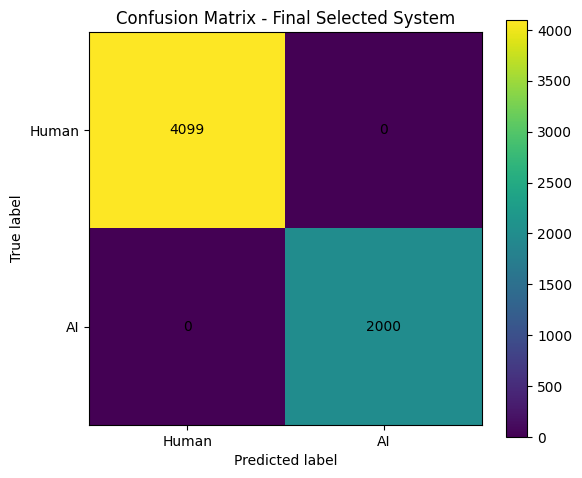

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Final Selected System")
plt.colorbar()
plt.xticks([0, 1], ["Human", "AI"])
plt.yticks([0, 1], ["Human", "AI"])
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

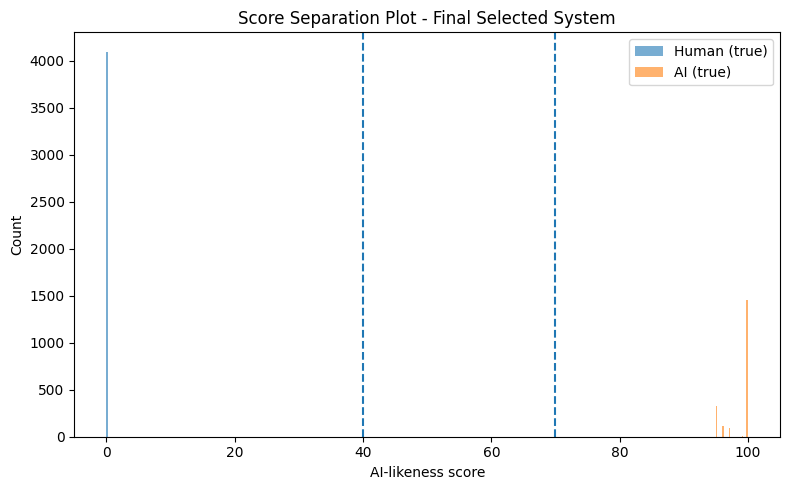

In [66]:
plt.figure(figsize=(8, 5))

human_scores = test_results_df.loc[test_results_df["true_label"] == "Human", "ai_likeness_score"]
ai_scores = test_results_df.loc[test_results_df["true_label"] == "AI", "ai_likeness_score"]

plt.hist(human_scores, bins=20, alpha=0.6, label="Human (true)")
plt.hist(ai_scores, bins=20, alpha=0.6, label="AI (true)")

plt.axvline(40, linestyle="--")
plt.axvline(70, linestyle="--")

plt.xlabel("AI-likeness score")
plt.ylabel("Count")
plt.title("Score Separation Plot - Final Selected System")
plt.legend()
plt.tight_layout()
plt.show()

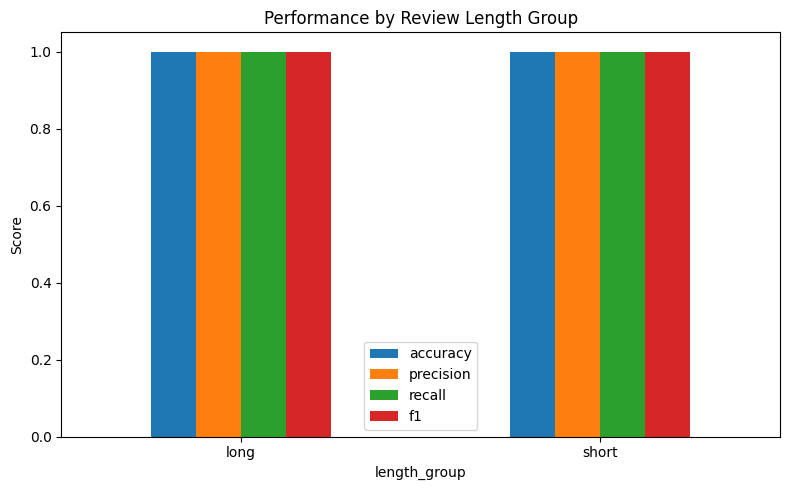

In [67]:
plot_df = subgroup_df.set_index("length_group")[["accuracy", "precision", "recall", "f1"]]

plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Performance by Review Length Group")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [68]:
def normalized_for_audit(text: str) -> str:
    text = normalize_review_text(str(text)).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

test_results_df["normalized_text"] = test_results_df["review_text"].apply(normalized_for_audit)

duplicate_counts = test_results_df["normalized_text"].value_counts()
possible_duplicates = duplicate_counts[duplicate_counts > 1]

print("Number of duplicated normalized texts in test set:", len(possible_duplicates))
possible_duplicates.head(10)

Number of duplicated normalized texts in test set: 131


,count
normalized_text,
"the hotel itself was lovely, very clean and the staff were genuinely friendly. however, the breakfast was a real letdown. the pastries were stale, and the fruit selection was limited to bruised bananas. honestly, i've had better continental breakfasts at budget motels – a significant disappointment for the price.",56
"the breakfast buffet was a mixed bag. there was a decent selection of pastries and fruit, but the hot options – scrambled eggs and bacon – were consistently lukewarm. coffee was plentiful, thankfully, and the staff were friendly enough, though a little slow to refill plates. overall, adequate for a start to the day.",51
"we absolutely loved our stay at the grandview! the location was fantastic and the staff were incredibly friendly. however, the street noise was quite significant, especially at night. bring earplugs if you're a light sleeper – it definitely impacted our sleep quality. otherwise, a wonderful experience!",47
"the hotel offered a solid selection of amenities. the gym was well-equipped with modern machines, and the pool area was clean and spacious. while the wi-fi was occasionally spotty, the complimentary coffee station in the lobby was a nice touch. parking was readily available, which was a definite plus.",47
"we found the hotel to be generally pleasant, but the noise levels were a significant issue. street traffic was incredibly loud at night, and thin walls meant we could hear conversations from neighboring rooms. it made it difficult to sleep. would recommend earplugs.",46
"we stayed two nights and found the rooms to be clean and comfortable, though a little dated. the included breakfast was a nice perk, offering a decent selection of options. considering the price point, it provided good value for money in that area – a perfectly acceptable, no-frills stay.",46
"absolutely fantastic location! we were able to walk everywhere – the harbor, the shops, even the castle. seriously, it couldn't be more central. we spent less time in taxis and more time exploring, which was exactly what we wanted. highly recommend if you want to be in the heart of things!",45
"""the location was fantastic, right by the harbor and easy to walk everywhere. however, the room was a little dated and the breakfast was incredibly basic – just toast and jam. for the price, it's definitely a good value, but don't expect luxury. would stay again if i needed a convenient base.""",45
"absolutely fantastic stay! the breakfast was the highlight – seriously, the best i've had in ages. fresh berries, perfectly cooked bacon, and a huge selection of pastries. they even had a lovely little outdoor seating area. definitely recommend starting your day here!",44


In [69]:
uncertain_cases = test_results_df[test_results_df["uncertainty_band"] == "uncertain"].copy()

print("Number of uncertain cases:", len(uncertain_cases))

uncertain_cases[[
    "review_text",
    "true_label",
    "predicted_label",
    "ai_probability",
    "ai_likeness_score",
    "top_features",
    "explanation"
]].head(10)

Number of uncertain cases: 0


,review_text,true_label,predicted_label,ai_probability,ai_likeness_score,top_features,explanation


In [70]:
week5_outputs = {
    "full_test_metrics": {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    },
    "matched_sample_metrics": {
        "accuracy": matched_acc,
        "precision": matched_prec,
        "recall": matched_rec,
        "f1": matched_f1
    },
    "comparison_summary": comparison_summary,
    "matched_comparison": matched_comparison,
    "subgroup_df": subgroup_df,
    "uncertainty_summary": uncertainty_summary,
    "test_results_df": test_results_df
}

with open("week5_outputs.pkl", "wb") as f:
    pickle.dump(week5_outputs, f)

print("Saved week5_outputs.pkl")

Saved week5_outputs.pkl


In [71]:
print("=" * 80)
print("WEEK 5 SUMMARY")
print("=" * 80)

print("\nFull selected-system test performance:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nWeek 2 baseline:")
print(f"Accuracy:  {baseline_results['accuracy']:.4f}")
print(f"Precision: {baseline_results['precision']:.4f}")
print(f"Recall:    {baseline_results['recall']:.4f}")
print(f"F1-score:  {baseline_results['f1']:.4f}")

print("\nF1 improvement over baseline:")
print(f"{f1 - baseline_results['f1']:+.4f}")

print("\nSubgroup results:")
print(subgroup_df.to_string(index=False))

print("\nUncertainty-band breakdown:")
print(uncertainty_summary.to_string(index=False))

WEEK 5 SUMMARY

Full selected-system test performance:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000

Week 2 baseline:
Accuracy:  0.7400
Precision: 0.5833
Recall:    0.2500
F1-score:  0.3500

F1 improvement over baseline:
+0.6500

Subgroup results:
length_group  n_reviews  accuracy  precision  recall  f1  avg_ai_probability  avg_ai_likeness_score
        long       3013       1.0        1.0     1.0 1.0            0.334340              33.447395
       short       3086       1.0        1.0     1.0 1.0            0.313811              31.380752

Uncertainty-band breakdown:
length_group     uncertainty_band  count  pct_within_group
        long  likely AI-generated   1017         33.753734
        long likely human-written   1996         66.246266
       short  likely AI-generated    983         31.853532
       short likely human-written   2103         68.146468


In [72]:
print("=" * 80)
print("WEEK 5 AUDIT: DUPLICATES, ARTIFACTS, AND STRICTER EVALUATION")
print("=" * 80)

WEEK 5 AUDIT: DUPLICATES, ARTIFACTS, AND STRICTER EVALUATION


In [73]:
def normalized_for_overlap(text: str) -> str:
    text = normalize_review_text(str(text)).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["normalized_text"] = train_df["Review"].apply(normalized_for_overlap)
val_df["normalized_text"] = val_df["Review"].apply(normalized_for_overlap)
test_df["normalized_text"] = test_df["Review"].apply(normalized_for_overlap)

print("Added normalized_text to train, validation, and test splits.")

Added normalized_text to train, validation, and test splits.


In [74]:
train_set = set(train_df["normalized_text"])
val_set = set(val_df["normalized_text"])
test_set = set(test_df["normalized_text"])

train_val_overlap = train_set.intersection(val_set)
train_test_overlap = train_set.intersection(test_set)
val_test_overlap = val_set.intersection(test_set)

print("Exact normalized overlap counts:")
print("train ∩ validation:", len(train_val_overlap))
print("train ∩ test:", len(train_test_overlap))
print("validation ∩ test:", len(val_test_overlap))

Exact normalized overlap counts:
train ∩ validation: 217
train ∩ test: 227
validation ∩ test: 171


In [75]:
def show_examples(name, overlap_set, n=10):
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    if len(overlap_set) == 0:
        print("No exact normalized overlaps found.")
    else:
        for i, text in enumerate(list(overlap_set)[:n], 1):
            print(f"{i}. {text[:300]}")
            print()

show_examples("TRAIN ∩ VALIDATION", train_val_overlap)
show_examples("TRAIN ∩ TEST", train_test_overlap)
show_examples("VALIDATION ∩ TEST", val_test_overlap)


TRAIN ∩ VALIDATION
1. honestly, the grandview hotel had a real mixed bag going on. the location is fantastic – right across from the beach and within walking distance of everything in town. that's a huge plus! however, the amenities were a bit hit and miss. the pool area was surprisingly small and always crowded, and the

2. honestly, our stay at the grandview hotel was a bit of a rollercoaster. the location is fantastic – right across from the beach and within walking distance of everything in town. that's definitely a huge plus. the staff were incredibly friendly and helpful, always willing to offer recommendations an

3. we absolutely loved our stay at the willow creek inn! the rooms were comfortable and clean, and the staff were incredibly friendly, but honestly, the breakfast was the real highlight. they had a fantastic spread every morning – fresh fruit platters overflowing with seasonal berries, a proper full en

4. we absolutely loved our stay at the grandview hotel! the locat

In [76]:
def duplicate_summary(df, split_name):
    counts = df["normalized_text"].value_counts()
    dup_counts = counts[counts > 1]
    print("\n" + "=" * 80)
    print(f"{split_name} duplicate summary")
    print("=" * 80)
    print("Total rows:", len(df))
    print("Unique normalized texts:", df["normalized_text"].nunique())
    print("Number of duplicated normalized texts:", len(dup_counts))
    if len(dup_counts) > 0:
        print("\nTop duplicates:")
        print(dup_counts.head(10))

duplicate_summary(train_df, "TRAIN")
duplicate_summary(val_df, "VALIDATION")
duplicate_summary(test_df, "TEST")


TRAIN duplicate summary
Total rows: 18294
Unique normalized texts: 12943
Number of duplicated normalized texts: 279

Top duplicates:
normalized_text
absolutely fantastic stay! the breakfast was the highlight – seriously, the best i've had in ages. fresh berries, perfectly cooked bacon, and a huge selection of pastries. they even had a lovely little outdoor seating area. definitely recommend starting your day here!                                                      162
the location was fantastic, right by the harbor, and the breakfast was lovely. however, we were incredibly disturbed by street noise – sirens all night and construction starting early. bring earplugs! the staff were friendly and helpful, but honestly, the noise significantly impacted our sleep and overall experience.    148
the hotel itself was lovely, very clean and the staff were genuinely friendly. however, the breakfast was a real letdown. the pastries were stale, and the fruit selection was limited to bruised bana

In [77]:
train_ai = train_df[train_df["label"] == 1].copy()
val_ai = val_df[val_df["label"] == 1].copy()
test_ai = test_df[test_df["label"] == 1].copy()

duplicate_summary(train_ai, "TRAIN AI")
duplicate_summary(val_ai, "VALIDATION AI")
duplicate_summary(test_ai, "TEST AI")


TRAIN AI duplicate summary
Total rows: 6000
Unique normalized texts: 649
Number of duplicated normalized texts: 279

Top duplicates:
normalized_text
absolutely fantastic stay! the breakfast was the highlight – seriously, the best i've had in ages. fresh berries, perfectly cooked bacon, and a huge selection of pastries. they even had a lovely little outdoor seating area. definitely recommend starting your day here!                                                      162
the location was fantastic, right by the harbor, and the breakfast was lovely. however, we were incredibly disturbed by street noise – sirens all night and construction starting early. bring earplugs! the staff were friendly and helpful, but honestly, the noise significantly impacted our sleep and overall experience.    148
the hotel itself was lovely, very clean and the staff were genuinely friendly. however, the breakfast was a real letdown. the pastries were stale, and the fruit selection was limited to bruised bana

In [78]:
def first_n_words(text, n=8):
    words = str(text).split()
    return " ".join(words[:n]).lower()

ai_full = full_df[full_df["label"] == 1].copy()
ai_full["opening_8_words"] = ai_full["Review"].apply(lambda x: first_n_words(x, 8))

opening_counts = ai_full["opening_8_words"].value_counts()

print("Most common AI review openings:")
print(opening_counts.head(20))

Most common AI review openings:
opening_8_words
okay, here’s a tripadvisor-style hotel review following your    2661
we absolutely loved our stay at the mariner’s                    617
we absolutely loved our stay at the grandview!                   477
we stayed at the grandview hotel for three                       389
we absolutely loved our stay at the willow                       372
we stayed at the grandview hotel for a                           326
absolutely fantastic stay! the breakfast was the highlight       265
the location was fantastic, right by the harbor,                 253
the breakfast buffet was a mixed bag. there                      243
absolutely fantastic location! we were able to walk              240
we found the hotel to be generally pleasant,                     239
we stayed two nights and found the rooms                         239
the hotel offered a solid selection of amenities.                237
we just returned from a wonderful three-night stay     

In [79]:
boilerplate_patterns = [
    "tripadvisor-style hotel review",
    "here's a tripadvisor-style hotel review",
    "okay, here's a tripadvisor-style hotel review",
    "sure, here's a tripadvisor-style hotel review",
    "hotel review:"
]

for phrase in boilerplate_patterns:
    count = full_df["Review"].astype(str).str.lower().str.contains(phrase, regex=False).sum()
    print(f"'{phrase}' -> {count} matches")

'tripadvisor-style hotel review' -> 2933 matches
'here's a tripadvisor-style hotel review' -> 0 matches
'okay, here's a tripadvisor-style hotel review' -> 0 matches
'sure, here's a tripadvisor-style hotel review' -> 0 matches
'hotel review:' -> 0 matches


In [80]:
dedup_df = full_df.copy()
dedup_df["normalized_text"] = dedup_df["Review"].apply(normalized_for_overlap)

before_rows = len(dedup_df)
dedup_df = dedup_df.drop_duplicates(subset=["normalized_text"]).reset_index(drop=True)
after_rows = len(dedup_df)

print("Rows before deduplication:", before_rows)
print("Rows after deduplication:", after_rows)
print("Rows removed:", before_rows - after_rows)

print("\nLabel counts after deduplication:")
print(dedup_df["label"].value_counts())

Rows before deduplication: 30491
Rows after deduplication: 21358
Rows removed: 9133

Label counts after deduplication:
label
0    20491
1      867
Name: count, dtype: int64


In [81]:
train_df_dedup, temp_df_dedup = train_test_split(
    dedup_df,
    test_size=0.4,
    stratify=dedup_df["label"],
    random_state=42
)

val_df_dedup, test_df_dedup = train_test_split(
    temp_df_dedup,
    test_size=0.5,
    stratify=temp_df_dedup["label"],
    random_state=42
)

print("Deduplicated split sizes:")
print("Train:", len(train_df_dedup))
print("Validation:", len(val_df_dedup))
print("Test:", len(test_df_dedup))

print("\nAI percentage by deduplicated split:")
print("Train:", round(train_df_dedup["label"].mean() * 100, 2), "%")
print("Validation:", round(val_df_dedup["label"].mean() * 100, 2), "%")
print("Test:", round(test_df_dedup["label"].mean() * 100, 2), "%")

Deduplicated split sizes:
Train: 12814
Validation: 4272
Test: 4272

AI percentage by deduplicated split:
Train: 4.06 %
Validation: 4.07 %
Test: 4.05 %


In [83]:
# ============================================================================
# CHECK WHETHER ANY EXACT NORMALIZED TEXT APPEARS IN BOTH HUMAN AND AI
# ============================================================================

human_norm_set = set(full_df[full_df["label"] == 0]["Review"].apply(normalized_for_overlap))
ai_norm_set = set(full_df[full_df["label"] == 1]["Review"].apply(normalized_for_overlap))

cross_label_overlap = human_norm_set.intersection(ai_norm_set)

print("Exact normalized overlap between human and AI texts:", len(cross_label_overlap))

for i, text in enumerate(list(cross_label_overlap)[:10], 1):
    print(f"\n{i}. {text[:400]}")

Exact normalized overlap between human and AI texts: 0


In [84]:
# ============================================================================
# BUILD LABEL-WISE DEDUPLICATED DATASET
# ============================================================================

human_only = full_df[full_df["label"] == 0].copy()
ai_only = full_df[full_df["label"] == 1].copy()

human_only["normalized_text"] = human_only["Review"].apply(normalized_for_overlap)
ai_only["normalized_text"] = ai_only["Review"].apply(normalized_for_overlap)

human_before = len(human_only)
ai_before = len(ai_only)

human_only = human_only.drop_duplicates(subset=["normalized_text"]).reset_index(drop=True)
ai_only = ai_only.drop_duplicates(subset=["normalized_text"]).reset_index(drop=True)

human_after = len(human_only)
ai_after = len(ai_only)

dedup_df = pd.concat([
    human_only[["Review", "label", "normalized_text"]],
    ai_only[["Review", "label", "normalized_text"]]
], ignore_index=True)

print("Human rows before deduplication:", human_before)
print("Human rows after deduplication:", human_after)
print("Human rows removed:", human_before - human_after)

print("\nAI rows before deduplication:", ai_before)
print("AI rows after deduplication:", ai_after)
print("AI rows removed:", ai_before - ai_after)

print("\nFinal label-wise deduplicated dataset size:", len(dedup_df))
print("\nLabel counts after label-wise deduplication:")
print(dedup_df["label"].value_counts())

Human rows before deduplication: 20491
Human rows after deduplication: 20491
Human rows removed: 0

AI rows before deduplication: 10000
AI rows after deduplication: 867
AI rows removed: 9133

Final label-wise deduplicated dataset size: 21358

Label counts after label-wise deduplication:
label
0    20491
1      867
Name: count, dtype: int64


In [85]:
# ============================================================================
# SPLIT LABEL-WISE DEDUPLICATED DATASET
# ============================================================================

train_df_dedup, temp_df_dedup = train_test_split(
    dedup_df,
    test_size=0.4,
    stratify=dedup_df["label"],
    random_state=42
)

val_df_dedup, test_df_dedup = train_test_split(
    temp_df_dedup,
    test_size=0.5,
    stratify=temp_df_dedup["label"],
    random_state=42
)

print("Deduplicated split sizes:")
print("Train:", len(train_df_dedup))
print("Validation:", len(val_df_dedup))
print("Test:", len(test_df_dedup))

print("\nAI percentage by deduplicated split:")
print("Train:", round(train_df_dedup["label"].mean() * 100, 2), "%")
print("Validation:", round(val_df_dedup["label"].mean() * 100, 2), "%")
print("Test:", round(test_df_dedup["label"].mean() * 100, 2), "%")

Deduplicated split sizes:
Train: 12814
Validation: 4272
Test: 4272

AI percentage by deduplicated split:
Train: 4.06 %
Validation: 4.07 %
Test: 4.05 %


In [86]:
# ============================================================================
# SPLIT LABEL-WISE DEDUPLICATED DATASET
# ============================================================================

train_df_dedup, temp_df_dedup = train_test_split(
    dedup_df,
    test_size=0.4,
    stratify=dedup_df["label"],
    random_state=42
)

val_df_dedup, test_df_dedup = train_test_split(
    temp_df_dedup,
    test_size=0.5,
    stratify=temp_df_dedup["label"],
    random_state=42
)

print("Deduplicated split sizes:")
print("Train:", len(train_df_dedup))
print("Validation:", len(val_df_dedup))
print("Test:", len(test_df_dedup))

print("\nAI percentage by deduplicated split:")
print("Train:", round(train_df_dedup["label"].mean() * 100, 2), "%")
print("Validation:", round(val_df_dedup["label"].mean() * 100, 2), "%")
print("Test:", round(test_df_dedup["label"].mean() * 100, 2), "%")

Deduplicated split sizes:
Train: 12814
Validation: 4272
Test: 4272

AI percentage by deduplicated split:
Train: 4.06 %
Validation: 4.07 %
Test: 4.05 %


In [87]:
# ============================================================================
# FAST CLASSIFIER-ONLY DETECTOR FOR BULK AUDIT
# ============================================================================

def detect_hotel_review_fast(review_text: str) -> dict:
    features = extract_week3_features(review_text)

    classifier_output = run_classifier_on_features(
        features=features,
        model_name=selected_model_name,
        use_calibration=True
    )

    return {
        "review_text": review_text,
        "model_used": classifier_output["model_used"],
        "calibrated": classifier_output["calibrated"],
        "ai_probability": round(classifier_output["ai_probability"], 4),
        "ai_likeness_score": classifier_output["ai_likeness_score"],
        "uncertainty_band": classifier_output["uncertainty_band"],
        "predicted_label": classifier_output["predicted_label"],
        "top_features": classifier_output["top_features"]
    }

print("detect_hotel_review_fast() is ready.")

detect_hotel_review_fast() is ready.


In [88]:
# ============================================================================
# PROVISIONAL AUDIT ON LABEL-WISE DEDUPLICATED TEST SPLIT
# NOTE: current saved model is still the original model, not retrained on dedup
# ============================================================================

dedup_test_outputs = []

for _, row in tqdm(test_df_dedup.iterrows(), total=len(test_df_dedup)):
    out = detect_hotel_review_fast(row["Review"])
    out["true_label"] = "AI" if row["label"] == 1 else "Human"
    out["true_label_binary"] = int(row["label"])
    dedup_test_outputs.append(out)

dedup_test_results_df = pd.DataFrame(dedup_test_outputs)

y_true_dedup = dedup_test_results_df["true_label_binary"].values
y_pred_dedup = (dedup_test_results_df["predicted_label"] == "AI").astype(int).values

acc_dedup = accuracy_score(y_true_dedup, y_pred_dedup)
prec_dedup, rec_dedup, f1_dedup, _ = precision_recall_fscore_support(
    y_true_dedup, y_pred_dedup, average="binary", zero_division=0
)
cm_dedup = confusion_matrix(y_true_dedup, y_pred_dedup)

print("=" * 80)
print("DEDUPLICATED TEST RESULTS (PROVISIONAL AUDIT)")
print("=" * 80)
print(f"Accuracy:  {acc_dedup:.4f}")
print(f"Precision: {prec_dedup:.4f}")
print(f"Recall:    {rec_dedup:.4f}")
print(f"F1-score:  {f1_dedup:.4f}")
print("\nConfusion Matrix:")
print(cm_dedup)

100%|██████████| 4272/4272 [05:37<00:00, 12.66it/s]

DEDUPLICATED TEST RESULTS (PROVISIONAL AUDIT)
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000

Confusion Matrix:
[[4099    0]
 [   0  173]]


In [89]:
# ============================================================================
# ORIGINAL VS LABEL-WISE DEDUPLICATED COMPARISON
# ============================================================================

orig_vs_dedup = pd.DataFrame([
    {
        "Evaluation": "Original test split",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    },
    {
        "Evaluation": "Label-wise deduplicated test split",
        "Accuracy": acc_dedup,
        "Precision": prec_dedup,
        "Recall": rec_dedup,
        "F1": f1_dedup
    }
])

orig_vs_dedup["F1_drop_from_original"] = orig_vs_dedup["F1"] - f1
orig_vs_dedup

,Evaluation,Accuracy,Precision,Recall,F1,F1_drop_from_original
0,Original test split,1.0,1.0,1.0,1.0,0.0
1,Label-wise deduplicated test split,1.0,1.0,1.0,1.0,0.0


In [90]:
# ============================================================================
# UNCERTAIN CASES ON LABEL-WISE DEDUPLICATED TEST SPLIT
# ============================================================================

dedup_uncertain_cases = dedup_test_results_df[
    dedup_test_results_df["uncertainty_band"] == "uncertain"
].copy()

print("Number of uncertain cases on deduplicated test split:", len(dedup_uncertain_cases))

dedup_uncertain_cases[[
    "review_text",
    "true_label",
    "predicted_label",
    "ai_probability",
    "ai_likeness_score",
    "top_features"
]].head(10)

Number of uncertain cases on deduplicated test split: 0


,review_text,true_label,predicted_label,ai_probability,ai_likeness_score,top_features


In [91]:
# ============================================================================
# SAVE AUDIT OUTPUTS
# ============================================================================

audit_outputs = {
    "cross_label_overlap_count": len(cross_label_overlap),
    "train_val_overlap_count": len(train_val_overlap),
    "train_test_overlap_count": len(train_test_overlap),
    "val_test_overlap_count": len(val_test_overlap),
    "orig_vs_dedup": orig_vs_dedup,
    "dedup_test_metrics": {
        "accuracy": acc_dedup,
        "precision": prec_dedup,
        "recall": rec_dedup,
        "f1": f1_dedup
    },
    "opening_counts": opening_counts,
    "dedup_test_results_df": dedup_test_results_df
}

with open("week5_audit_outputs.pkl", "wb") as f:
    pickle.dump(audit_outputs, f)

print("Saved week5_audit_outputs.pkl")

Saved week5_audit_outputs.pkl


In [92]:
# ============================================================================
# AUDIT SUMMARY
# ============================================================================

print("=" * 80)
print("WEEK 5 AUDIT SUMMARY")
print("=" * 80)

print("\nCross-label exact overlap:", len(cross_label_overlap))
print("Train ∩ Validation overlap:", len(train_val_overlap))
print("Train ∩ Test overlap:", len(train_test_overlap))
print("Validation ∩ Test overlap:", len(val_test_overlap))

print("\nOriginal full-test metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nLabel-wise deduplicated test metrics:")
print(f"Accuracy:  {acc_dedup:.4f}")
print(f"Precision: {prec_dedup:.4f}")
print(f"Recall:    {rec_dedup:.4f}")
print(f"F1-score:  {f1_dedup:.4f}")

print("\nOriginal vs label-wise deduplicated:")
print(orig_vs_dedup.to_string(index=False))

print("\nTop repeated AI openings:")
print(opening_counts.head(10).to_string())

print("\nUncertain cases on deduplicated split:", len(dedup_uncertain_cases))

WEEK 5 AUDIT SUMMARY

Cross-label exact overlap: 0
Train ∩ Validation overlap: 217
Train ∩ Test overlap: 227
Validation ∩ Test overlap: 171

Original full-test metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000

Label-wise deduplicated test metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000

Original vs label-wise deduplicated:
                        Evaluation  Accuracy  Precision  Recall  F1  F1_drop_from_original
               Original test split       1.0        1.0     1.0 1.0                    0.0
Label-wise deduplicated test split       1.0        1.0     1.0 1.0                    0.0

Top repeated AI openings:
opening_8_words
okay, here’s a tripadvisor-style hotel review following your    2661
we absolutely loved our stay at the mariner’s                    617
we absolutely loved our stay at the grandview!                   477
we stayed at the grandview hotel for three                       389
we absolutely love

In [93]:
print("=" * 80)
print("AUDIT INTERPRETATION")
print("=" * 80)

print("""
Key findings from the audit:

1. There is no exact normalized overlap between human and AI texts, so the model is not exploiting direct cross-label duplicates.

2. However, there is substantial exact overlap across train, validation, and test splits, which indicates leakage through repeated texts across splits.

3. The duplication problem is concentrated in the AI data. After label-wise deduplication, the human dataset remained at 20,491 reviews, while the AI dataset dropped from 10,000 to 867 unique normalized reviews.

4. Repeated AI review openings are also very common, suggesting strong template-like generation patterns.

5. Even after label-wise deduplication, performance remained perfect, which suggests that the classifier is still benefiting from residual synthetic artifacts or highly repetitive stylistic cues.

Conclusion:
The current results should be treated as preliminary and likely inflated. The model appears to detect this synthetic AI dataset very well, but additional data cleaning or more diverse AI generation is needed before claiming robust generalization.
""")

AUDIT INTERPRETATION

Key findings from the audit:

1. There is no exact normalized overlap between human and AI texts, so the model is not exploiting direct cross-label duplicates.

2. However, there is substantial exact overlap across train, validation, and test splits, which indicates leakage through repeated texts across splits.

3. The duplication problem is concentrated in the AI data. After label-wise deduplication, the human dataset remained at 20,491 reviews, while the AI dataset dropped from 10,000 to 867 unique normalized reviews.

4. Repeated AI review openings are also very common, suggesting strong template-like generation patterns.

5. Even after label-wise deduplication, performance remained perfect, which suggests that the classifier is still benefiting from residual synthetic artifacts or highly repetitive stylistic cues.

Conclusion:
The current results should be treated as preliminary and likely inflated. The model appears to detect this synthetic AI dataset very we

In [94]:
print("=" * 80)
print("WEEK 5 CLEAN RETRAINING ON LABEL-WISE DEDUPLICATED DATA")
print("=" * 80)

WEEK 5 CLEAN RETRAINING ON LABEL-WISE DEDUPLICATED DATA


In [95]:
from tqdm import tqdm
import numpy as np
import pandas as pd

def build_feature_matrix(df):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        feats = extract_week3_features(row["Review"])
        rows.append(feats)
    X = pd.DataFrame(rows)[feature_columns].copy()
    y = df["label"].astype(int).values
    return X, y

print("Extracting deduplicated train features...")
X_train_dedup, y_train_dedup = build_feature_matrix(train_df_dedup)

print("Extracting deduplicated validation features...")
X_val_dedup, y_val_dedup = build_feature_matrix(val_df_dedup)

print("Extracting deduplicated test features...")
X_test_dedup, y_test_dedup = build_feature_matrix(test_df_dedup)

print("\nShapes:")
print("X_train_dedup:", X_train_dedup.shape)
print("X_val_dedup:", X_val_dedup.shape)
print("X_test_dedup:", X_test_dedup.shape)

Extracting deduplicated train features...


100%|██████████| 12814/12814 [00:32<00:00, 399.94it/s]


Extracting deduplicated validation features...


100%|██████████| 4272/4272 [00:14<00:00, 288.47it/s]


Extracting deduplicated test features...


100%|██████████| 4272/4272 [00:08<00:00, 496.69it/s]


Shapes:
X_train_dedup: (12814, 14)
X_val_dedup: (4272, 14)
X_test_dedup: (4272, 14)


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

lr_dedup = LogisticRegression(
    max_iter=2000,
    random_state=42
)

rf_dedup = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Training deduplicated logistic regression...")
lr_dedup.fit(X_train_dedup, y_train_dedup)

print("Training deduplicated random forest...")
rf_dedup.fit(X_train_dedup, y_train_dedup)

print("Done training on deduplicated split.")

Training deduplicated logistic regression...
Training deduplicated random forest...
Done training on deduplicated split.


In [97]:
def evaluate_binary_model(model, X, y, model_name, split_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    acc_ = accuracy_score(y, y_pred)
    prec_, rec_, f1_, _ = precision_recall_fscore_support(
        y, y_pred, average="binary", zero_division=0
    )
    cm_ = confusion_matrix(y, y_pred)

    print("\n" + "=" * 80)
    print(f"{model_name} | {split_name} | BEFORE CALIBRATION")
    print("=" * 80)
    print(f"Accuracy:  {acc_:.4f}")
    print(f"Precision: {prec_:.4f}")
    print(f"Recall:    {rec_:.4f}")
    print(f"F1-score:  {f1_:.4f}")
    print("Confusion Matrix:")
    print(cm_)

    return {
        "accuracy": acc_,
        "precision": prec_,
        "recall": rec_,
        "f1": f1_,
        "cm": cm_,
        "prob": y_prob
    }

lr_val_before = evaluate_binary_model(lr_dedup, X_val_dedup, y_val_dedup, "Logistic Regression", "Validation")
lr_test_before = evaluate_binary_model(lr_dedup, X_test_dedup, y_test_dedup, "Logistic Regression", "Test")

rf_val_before = evaluate_binary_model(rf_dedup, X_val_dedup, y_val_dedup, "Random Forest", "Validation")
rf_test_before = evaluate_binary_model(rf_dedup, X_test_dedup, y_test_dedup, "Random Forest", "Test")


Logistic Regression | Validation | BEFORE CALIBRATION
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion Matrix:
[[4098    0]
 [   0  174]]

Logistic Regression | Test | BEFORE CALIBRATION
Accuracy:  0.9998
Precision: 1.0000
Recall:    0.9942
F1-score:  0.9971
Confusion Matrix:
[[4099    0]
 [   1  172]]

Random Forest | Validation | BEFORE CALIBRATION
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion Matrix:
[[4098    0]
 [   0  174]]

Random Forest | Test | BEFORE CALIBRATION
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion Matrix:
[[4099    0]
 [   0  173]]


In [98]:
from scipy.optimize import minimize

class TemperatureScalerFit:
    def __init__(self):
        self.temperature = 1.0

    def fit(self, probs, true_labels):
        probs = np.asarray(probs, dtype=float)
        y = np.asarray(true_labels, dtype=float)
        eps = 1e-12

        def objective(t_arr):
            t = float(t_arr[0])
            t = max(t, 1e-3)

            logits = np.log((probs + eps) / (1 - probs + eps))
            scaled = 1 / (1 + np.exp(-(logits / t)))
            scaled = np.clip(scaled, eps, 1 - eps)

            loss = -np.mean(y * np.log(scaled) + (1 - y) * np.log(1 - scaled))
            return loss

        res = minimize(objective, x0=np.array([1.0]), bounds=[(1e-3, 100.0)])
        self.temperature = float(res.x[0])
        return self

    def predict_proba(self, probs):
        probs = np.asarray(probs, dtype=float)
        eps = 1e-12
        logits = np.log((probs + eps) / (1 - probs + eps))
        scaled = 1 / (1 + np.exp(-(logits / self.temperature)))
        return np.clip(scaled, 0.0, 1.0)

lr_temp_scaler_dedup = TemperatureScalerFit().fit(lr_val_before["prob"], y_val_dedup)
rf_temp_scaler_dedup = TemperatureScalerFit().fit(rf_val_before["prob"], y_val_dedup)

print("Deduplicated LR temperature:", lr_temp_scaler_dedup.temperature)
print("Deduplicated RF temperature:", rf_temp_scaler_dedup.temperature)

Deduplicated LR temperature: 0.001
Deduplicated RF temperature: 0.1932729067123363


/tmp/ipykernel_28853/4228788922.py:17: RuntimeWarning: overflow encountered in exp
  scaled = 1 / (1 + np.exp(-(logits / t)))


In [99]:
def evaluate_calibrated_probs(raw_probs, y_true, scaler, model_name):
    calibrated_probs = scaler.predict_proba(raw_probs)
    y_pred = (calibrated_probs >= 0.5).astype(int)

    acc_ = accuracy_score(y_true, y_pred)
    prec_, rec_, f1_, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    cm_ = confusion_matrix(y_true, y_pred)

    print("\n" + "=" * 80)
    print(f"{model_name} | DEDUP TEST | AFTER CALIBRATION")
    print("=" * 80)
    print(f"Accuracy:  {acc_:.4f}")
    print(f"Precision: {prec_:.4f}")
    print(f"Recall:    {rec_:.4f}")
    print(f"F1-score:  {f1_:.4f}")
    print("Confusion Matrix:")
    print(cm_)

    return {
        "accuracy": acc_,
        "precision": prec_,
        "recall": rec_,
        "f1": f1_,
        "cm": cm_,
        "prob": calibrated_probs
    }

lr_test_after = evaluate_calibrated_probs(
    lr_test_before["prob"], y_test_dedup, lr_temp_scaler_dedup, "Logistic Regression"
)

rf_test_after = evaluate_calibrated_probs(
    rf_test_before["prob"], y_test_dedup, rf_temp_scaler_dedup, "Random Forest"
)


Logistic Regression | DEDUP TEST | AFTER CALIBRATION
Accuracy:  0.9998
Precision: 1.0000
Recall:    0.9942
F1-score:  0.9971
Confusion Matrix:
[[4099    0]
 [   1  172]]

Random Forest | DEDUP TEST | AFTER CALIBRATION
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion Matrix:
[[4099    0]
 [   0  173]]


/tmp/ipykernel_28853/4228788922.py:31: RuntimeWarning: overflow encountered in exp
  scaled = 1 / (1 + np.exp(-(logits / self.temperature)))


In [100]:
retrained_comparison = pd.DataFrame([
    {
        "evaluation": "Original Week 5 full test",
        "model": "selected final system",
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    },
    {
        "evaluation": "Provisional dedup audit",
        "model": "old saved model on dedup split",
        "accuracy": acc_dedup,
        "precision": prec_dedup,
        "recall": rec_dedup,
        "f1": f1_dedup
    },
    {
        "evaluation": "Clean retrain on dedup split",
        "model": "logistic_regression_calibrated",
        "accuracy": lr_test_after["accuracy"],
        "precision": lr_test_after["precision"],
        "recall": lr_test_after["recall"],
        "f1": lr_test_after["f1"]
    },
    {
        "evaluation": "Clean retrain on dedup split",
        "model": "random_forest_calibrated",
        "accuracy": rf_test_after["accuracy"],
        "precision": rf_test_after["precision"],
        "recall": rf_test_after["recall"],
        "f1": rf_test_after["f1"]
    }
])

retrained_comparison["f1_drop_from_original"] = retrained_comparison["f1"] - f1
retrained_comparison

,evaluation,model,accuracy,precision,recall,f1,f1_drop_from_original
0,Original Week 5 full test,selected final system,1.000000,1.0,1.00000,1.000000,0.000000
1,Provisional dedup audit,old saved model on dedup split,1.000000,1.0,1.00000,1.000000,0.000000
2,Clean retrain on dedup split,logistic_regression_calibrated,0.999766,1.0,0.99422,0.997101,-0.002899
3,Clean retrain on dedup split,random_forest_calibrated,1.000000,1.0,1.00000,1.000000,0.000000


In [101]:
best_retrained_row = retrained_comparison[
    retrained_comparison["evaluation"] == "Clean retrain on dedup split"
].sort_values("f1", ascending=False).iloc[0]

print("Best clean retrained dedup model:")
print(best_retrained_row)

Best clean retrained dedup model:
evaluation               Clean retrain on dedup split
model                        random_forest_calibrated
accuracy                                          1.0
precision                                         1.0
recall                                            1.0
f1                                                1.0
f1_drop_from_original                             0.0
Name: 3, dtype: object


In [102]:
print("=" * 80)
print("CLEAN RETRAINING INTERPRETATION")
print("=" * 80)

print("""
This section retrains the classifiers from scratch on the label-wise deduplicated split,
rather than evaluating the old saved model on a new split.

Interpretation guide:
- If retrained deduplicated performance drops below 1.000, that means the earlier perfect
  results were at least partly inflated by repetition and leakage.
- If performance still remains extremely high, then the task is still being made easy by
  residual synthetic artifacts or strong template-like patterns in the AI reviews.
- The clean retrained deduplicated result is the more trustworthy estimate than the earlier
  provisional audit.
""")

CLEAN RETRAINING INTERPRETATION

This section retrains the classifiers from scratch on the label-wise deduplicated split,
rather than evaluating the old saved model on a new split.

Interpretation guide:
- If retrained deduplicated performance drops below 1.000, that means the earlier perfect
  results were at least partly inflated by repetition and leakage.
- If performance still remains extremely high, then the task is still being made easy by
  residual synthetic artifacts or strong template-like patterns in the AI reviews.
- The clean retrained deduplicated result is the more trustworthy estimate than the earlier
  provisional audit.



In [103]:
retrained_dedup_outputs = {
    "X_train_shape": X_train_dedup.shape,
    "X_val_shape": X_val_dedup.shape,
    "X_test_shape": X_test_dedup.shape,
    "lr_test_before": lr_test_before,
    "rf_test_before": rf_test_before,
    "lr_test_after": lr_test_after,
    "rf_test_after": rf_test_after,
    "lr_temperature": lr_temp_scaler_dedup.temperature,
    "rf_temperature": rf_temp_scaler_dedup.temperature,
    "retrained_comparison": retrained_comparison,
}

with open("week5_retrained_dedup_outputs.pkl", "wb") as f:
    pickle.dump(retrained_dedup_outputs, f)

print("Saved week5_retrained_dedup_outputs.pkl")

Saved week5_retrained_dedup_outputs.pkl


In [104]:
print("=" * 80)
print("HYBRID DETECTOR: STYLOMETRY + CHAR/WORLD N-GRAM TF-IDF")
print("=" * 80)

HYBRID DETECTOR: STYLOMETRY + CHAR/WORLD N-GRAM TF-IDF


In [105]:
train_df_dedup = train_df_dedup.copy()
val_df_dedup = val_df_dedup.copy()
test_df_dedup = test_df_dedup.copy()

train_df_dedup["clean_text"] = train_df_dedup["Review"].apply(normalize_review_text)
val_df_dedup["clean_text"] = val_df_dedup["Review"].apply(normalize_review_text)
test_df_dedup["clean_text"] = test_df_dedup["Review"].apply(normalize_review_text)

print("Clean text columns added.")

Clean text columns added.


In [106]:
def build_stylometry_matrix(df):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        rows.append(extract_week3_features(row["Review"]))
    X = pd.DataFrame(rows)[feature_columns].astype(float)
    return X

print("Building stylometry matrices...")
X_sty_train = build_stylometry_matrix(train_df_dedup)
X_sty_val = build_stylometry_matrix(val_df_dedup)
X_sty_test = build_stylometry_matrix(test_df_dedup)

y_train_hybrid = train_df_dedup["label"].astype(int).values
y_val_hybrid = val_df_dedup["label"].astype(int).values
y_test_hybrid = test_df_dedup["label"].astype(int).values

print("Stylometry shapes:")
print("train:", X_sty_train.shape)
print("val:", X_sty_val.shape)
print("test:", X_sty_test.shape)

Building stylometry matrices...


100%|██████████| 4272/4272 [00:19<00:00, 215.07it/s]


Stylometry shapes:
train: (12814, 14)
val: (4272, 14)
test: (4272, 14)


In [107]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Character n-grams are often strong for text-origin detection
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_features=20000,
    sublinear_tf=True
)

# Word n-grams add phrase-level signals
word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=10000,
    sublinear_tf=True
)

print("Fitting TF-IDF vectorizers on deduplicated training text...")
X_char_train = char_vectorizer.fit_transform(train_df_dedup["clean_text"])
X_char_val = char_vectorizer.transform(val_df_dedup["clean_text"])
X_char_test = char_vectorizer.transform(test_df_dedup["clean_text"])

X_word_train = word_vectorizer.fit_transform(train_df_dedup["clean_text"])
X_word_val = word_vectorizer.transform(val_df_dedup["clean_text"])
X_word_test = word_vectorizer.transform(test_df_dedup["clean_text"])

print("Character TF-IDF shapes:")
print("train:", X_char_train.shape)
print("val:", X_char_val.shape)
print("test:", X_char_test.shape)

print("\nWord TF-IDF shapes:")
print("train:", X_word_train.shape)
print("val:", X_word_val.shape)
print("test:", X_word_test.shape)

Fitting TF-IDF vectorizers on deduplicated training text...
Character TF-IDF shapes:
train: (12814, 20000)
val: (4272, 20000)
test: (4272, 20000)

Word TF-IDF shapes:
train: (12814, 10000)
val: (4272, 10000)
test: (4272, 10000)


In [108]:
from scipy.sparse import hstack, csr_matrix

X_sty_train_sparse = csr_matrix(X_sty_train.values)
X_sty_val_sparse = csr_matrix(X_sty_val.values)
X_sty_test_sparse = csr_matrix(X_sty_test.values)

X_train_hybrid = hstack([X_sty_train_sparse, X_char_train, X_word_train]).tocsr()
X_val_hybrid = hstack([X_sty_val_sparse, X_char_val, X_word_val]).tocsr()
X_test_hybrid = hstack([X_sty_test_sparse, X_char_test, X_word_test]).tocsr()

print("Hybrid feature shapes:")
print("train:", X_train_hybrid.shape)
print("val:", X_val_hybrid.shape)
print("test:", X_test_hybrid.shape)

Hybrid feature shapes:
train: (12814, 30014)
val: (4272, 30014)
test: (4272, 30014)


In [109]:
from sklearn.linear_model import LogisticRegression

hybrid_lr = LogisticRegression(
    max_iter=3000,
    C=2.0,
    class_weight="balanced",
    random_state=42
)

print("Training hybrid logistic regression...")
hybrid_lr.fit(X_train_hybrid, y_train_hybrid)
print("Hybrid model trained.")

Training hybrid logistic regression...
Hybrid model trained.


In [110]:
def evaluate_sparse_model(model, X, y, model_name, split_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    acc_ = accuracy_score(y, y_pred)
    prec_, rec_, f1_, _ = precision_recall_fscore_support(
        y, y_pred, average="binary", zero_division=0
    )
    cm_ = confusion_matrix(y, y_pred)

    print("\n" + "=" * 80)
    print(f"{model_name} | {split_name} | BEFORE CALIBRATION")
    print("=" * 80)
    print(f"Accuracy:  {acc_:.4f}")
    print(f"Precision: {prec_:.4f}")
    print(f"Recall:    {rec_:.4f}")
    print(f"F1-score:  {f1_:.4f}")
    print("Confusion Matrix:")
    print(cm_)

    return {
        "accuracy": acc_,
        "precision": prec_,
        "recall": rec_,
        "f1": f1_,
        "cm": cm_,
        "prob": y_prob
    }

hybrid_val_before = evaluate_sparse_model(
    hybrid_lr, X_val_hybrid, y_val_hybrid, "Hybrid LR", "Validation"
)

hybrid_test_before = evaluate_sparse_model(
    hybrid_lr, X_test_hybrid, y_test_hybrid, "Hybrid LR", "Test"
)


Hybrid LR | Validation | BEFORE CALIBRATION
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion Matrix:
[[4098    0]
 [   0  174]]

Hybrid LR | Test | BEFORE CALIBRATION
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion Matrix:
[[4099    0]
 [   0  173]]


In [111]:
hybrid_temp_scaler = TemperatureScalerFit().fit(
    hybrid_val_before["prob"], y_val_hybrid
)

print("Hybrid LR temperature:", hybrid_temp_scaler.temperature)

Hybrid LR temperature: 0.2156541840513527


In [112]:
hybrid_test_after = evaluate_calibrated_probs(
    hybrid_test_before["prob"],
    y_test_hybrid,
    hybrid_temp_scaler,
    "Hybrid LR"
)


Hybrid LR | DEDUP TEST | AFTER CALIBRATION
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Confusion Matrix:
[[4099    0]
 [   0  173]]


In [113]:
all_model_comparison = pd.DataFrame([
    {
        "model": "original_selected_system",
        "evaluation": "original week5 full test",
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    },
    {
        "model": "lr_retrained_dedup_calibrated",
        "evaluation": "clean retrain on dedup split",
        "accuracy": lr_test_after["accuracy"],
        "precision": lr_test_after["precision"],
        "recall": lr_test_after["recall"],
        "f1": lr_test_after["f1"]
    },
    {
        "model": "rf_retrained_dedup_calibrated",
        "evaluation": "clean retrain on dedup split",
        "accuracy": rf_test_after["accuracy"],
        "precision": rf_test_after["precision"],
        "recall": rf_test_after["recall"],
        "f1": rf_test_after["f1"]
    },
    {
        "model": "hybrid_lr_calibrated",
        "evaluation": "dedup split",
        "accuracy": hybrid_test_after["accuracy"],
        "precision": hybrid_test_after["precision"],
        "recall": hybrid_test_after["recall"],
        "f1": hybrid_test_after["f1"]
    }
])

all_model_comparison["f1_vs_original"] = all_model_comparison["f1"] - f1
all_model_comparison.sort_values(["f1", "accuracy"], ascending=False)

,model,evaluation,accuracy,precision,recall,f1,f1_vs_original
0,original_selected_system,original week5 full test,1.000000,1.0,1.00000,1.000000,0.000000
2,rf_retrained_dedup_calibrated,clean retrain on dedup split,1.000000,1.0,1.00000,1.000000,0.000000
3,hybrid_lr_calibrated,dedup split,1.000000,1.0,1.00000,1.000000,0.000000
1,lr_retrained_dedup_calibrated,clean retrain on dedup split,0.999766,1.0,0.99422,0.997101,-0.002899


In [114]:
hybrid_outputs = {
    "char_vectorizer": char_vectorizer,
    "word_vectorizer": word_vectorizer,
    "hybrid_model": hybrid_lr,
    "hybrid_temp_scaler": hybrid_temp_scaler,
    "hybrid_val_before": hybrid_val_before,
    "hybrid_test_before": hybrid_test_before,
    "hybrid_test_after": hybrid_test_after,
    "all_model_comparison": all_model_comparison
}

with open("week5_hybrid_detector_outputs.pkl", "wb") as f:
    pickle.dump(hybrid_outputs, f)

print("Saved week5_hybrid_detector_outputs.pkl")

Saved week5_hybrid_detector_outputs.pkl


In [115]:
print("=" * 80)
print("HYBRID DETECTOR INTERPRETATION")
print("=" * 80)
print("""
This hybrid model combines stylometric features with character and word n-gram TF-IDF.
Compared with stylometry-only models, it is a stronger detector because it can use both
high-level writing style signals and low-level textual patterns.

If hybrid performance remains perfect, that suggests the AI dataset is still highly separable.
If hybrid performance is strong but not perfect, that is a more realistic sign that the task
has become harder under the cleaned deduplicated setting.
""")

HYBRID DETECTOR INTERPRETATION

This hybrid model combines stylometric features with character and word n-gram TF-IDF.
Compared with stylometry-only models, it is a stronger detector because it can use both
high-level writing style signals and low-level textual patterns.

If hybrid performance remains perfect, that suggests the AI dataset is still highly separable.
If hybrid performance is strong but not perfect, that is a more realistic sign that the task
has become harder under the cleaned deduplicated setting.

